# Local zero-shot screening — no API required

Everything here runs on your own machine. Two approaches, both free:

**A. Zero-shot NLI classification.** A DeBERTa model trained on natural language
inference judges whether an abstract entails a hypothesis such as *"This study measures
an attribute of the pedestrian environment using sensors."* No training, no labels, no
API. This is the approach Costa et al. (2026) used for their domain classification stage
(Sect. 4.4, citing Laurer et al. 2023) — and `MoritzLaurer/deberta-v3-large-zeroshot-v2.0-c`
is the model the original `train.ipynb` referenced before switching to fine-tuning.

**B. Embedding similarity ranking.** Encode abstracts with a sentence transformer and
rank them by similarity to known-positive examples. Not a classifier — a *reading-order
prioritiser*, which is a legitimate and widely used mode in technology-assisted review
(O'Mara-Eves et al. 2015). Needs only a handful of seed examples.

Both are evaluated against `diagnostic_test.json`, so the numbers are directly
comparable to the fine-tuned DeBERTa.

> Model weights download from HuggingFace on first run (~1.5 GB for the large NLI model,
> ~90 MB for the sentence transformer). After that everything is offline. If disk or
> memory is tight, swap `-large-` for `-base-` in the model name.

In [3]:
# pip install transformers torch sentence-transformers scikit-learn --upgrade
import os, json, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

DATA_DIR = "../model/dataset"
OUT_DIR  = "../model/output"
os.makedirs(OUT_DIR, exist_ok=True)
POS = "Sensing of walkability dimension"
NEG = "Not related"

device = 0 if torch.cuda.is_available() else -1
print(f"CUDA: {torch.cuda.is_available()}")

diag = pd.DataFrame(json.load(open(f"{DATA_DIR}/diagnostic_test.json", encoding="utf-8")))
diag["y"] = (diag["label"] == POS).astype(int)
print(f"Diagnostic set: {len(diag)} real abstracts | {diag.y.mean()*100:.1f}% positive")


def wss_at_recall(y, score, target=0.95):
    """Work Saved over Sampling at a target recall (Cohen et al. 2006)."""
    best = None
    for thr in np.linspace(0.001, 0.999, 999):
        pred = (score >= thr).astype(int)
        rec = recall_score(y, pred, zero_division=0)
        if rec >= target:
            wss = (1 - pred.mean()) - (1 - rec)
            if best is None or wss > best[0]:
                best = (wss, thr, rec, pred.mean())
    return best


def sweep_table(y, score, name):
    rows = []
    for thr in np.linspace(0.05, 0.95, 19):
        pr = (score >= thr).astype(int)
        rows.append({"threshold": round(thr, 2),
                     "recall": round(recall_score(y, pr, zero_division=0), 3),
                     "precision": round(precision_score(y, pr, zero_division=0), 3),
                     "F1": round(f1_score(y, pr, zero_division=0), 3),
                     "pct_discarded": round(100 * (1 - pr.mean()), 1),
                     "eligible_missed": int(((y == 1) & (pr == 0)).sum())})
    t = pd.DataFrame(rows)
    t["lift"] = (t["precision"] / y.mean()).round(2)
    print(f"\n=== {name} ===")
    print(t.to_string(index=False))
    for tgt in (0.95, 0.90, 0.85):
        r = wss_at_recall(y, score, tgt)
        print(f"WSS@{int(tgt*100)}: " + ("UNREACHABLE" if r is None
              else f"{r[0]*100:5.1f}%  (threshold {r[1]:.3f}, recall {r[2]:.3f})"))
    return t

CUDA: True
Diagnostic set: 125 real abstracts | 39.2% positive


## A. Zero-shot NLI

The criterion cannot fit in one hypothesis, so it is split across several. Positive
hypotheses cover the Alfonzo dimensions; negative hypotheses cover the noise clusters
measured in the corpus. The score is the strongest positive entailment minus the
strongest negative one — that subtraction is what encodes "measures the pedestrian
environment, and not something else".

Tune the hypothesis wording here rather than retraining anything. Short, concrete,
declarative sentences work better than long ones.

In [4]:
from transformers import pipeline

NLI_MODEL = "MoritzLaurer/deberta-v3-large-zeroshot-v2.0"   # use -base- if memory-tight
clf = pipeline("zero-shot-classification", model=NLI_MODEL, device=device)
print(f"Loaded {NLI_MODEL}")

POS_HYPOTHESES = [
    "This study uses sensors to measure the physical condition of sidewalks or footpaths.",
    "This study measures pedestrian crossings, street lighting or traffic exposure with sensors.",
    "This study measures thermal comfort, noise or air quality at pedestrian level.",
    "This study measures street greenery, facades or visual quality from street-level images.",
    "This study measures slope, steps, ramps or accessibility barriers along pedestrian routes.",
]
NEG_HYPOTHESES = [
    "This study measures physical activity or health outcomes of participants.",
    "This study is about cyclists, e-scooters, drivers, robots or autonomous vehicles.",
    "This study uses satellite or aerial imagery as its main data source.",
    "This study analyses clinical gait or patient rehabilitation.",
    "This study computes an index from geographic databases without any sensor.",
    "This study uses simulation or modelling instead of field measurement.",
]
ALL_H = POS_HYPOTHESES + NEG_HYPOTHESES

scores = []
t0 = time.time()
for i, txt in enumerate(diag["text"]):
    out = clf(txt[:2000], ALL_H, multi_label=True)   # multi_label: independent scores
    d = dict(zip(out["labels"], out["scores"]))
    pos_max = max(d[h] for h in POS_HYPOTHESES)
    neg_max = max(d[h] for h in NEG_HYPOTHESES)
    scores.append({"pos_max": pos_max, "neg_max": neg_max,
                   "score": pos_max * (1 - neg_max),          # combined
                   "best_pos": max(POS_HYPOTHESES, key=lambda h: d[h]),
                   "best_neg": max(NEG_HYPOTHESES, key=lambda h: d[h])})
    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{len(diag)}  ({time.time()-t0:.0f}s)")

sc = pd.DataFrame(scores)
diag["nli_pos"] = sc["pos_max"].values
diag["nli_neg"] = sc["neg_max"].values
diag["nli_score"] = sc["score"].values
diag["nli_best_pos"] = sc["best_pos"].values
print(f"\nDone in {time.time()-t0:.0f}s")

y = diag["y"].values
t_nli = sweep_table(y, diag["nli_score"].values, "ZERO-SHOT NLI (combined score)")
_ = sweep_table(y, diag["nli_pos"].values, "ZERO-SHOT NLI (positive hypotheses only)")

Device set to use cuda:0


Loaded MoritzLaurer/deberta-v3-large-zeroshot-v2.0
  25/125  (70s)
  50/125  (140s)
  75/125  (216s)
  100/125  (297s)
  125/125  (376s)

Done in 376s

=== ZERO-SHOT NLI (combined score) ===
 threshold  recall  precision    F1  pct_discarded  eligible_missed  lift
      0.05   0.633      0.689 0.660           64.0               18  1.76
      0.10   0.551      0.730 0.628           70.4               22  1.86
      0.15   0.490      0.750 0.593           74.4               25  1.91
      0.20   0.449      0.786 0.571           77.6               27  2.01
      0.25   0.408      0.870 0.556           81.6               29  2.22
      0.30   0.388      0.864 0.535           82.4               30  2.20
      0.35   0.367      0.857 0.514           83.2               31  2.19
      0.40   0.327      0.889 0.478           85.6               33  2.27
      0.45   0.286      0.875 0.431           87.2               35  2.23
      0.50   0.265      0.867 0.406           88.0               36  

## B. Embedding similarity ranking

No classification at all: encode every abstract, encode a set of known-positive seeds,
and rank by cosine similarity. Screening then proceeds in ranked order and stops when
the density of eligible papers falls off.

This is the cheapest possible use of the labels you already have, and it needs no GPU.
Report it as *screening prioritisation*, not as automated exclusion.

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\vinic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vinic\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded sentence-transformers/all-mpnet-base-v2
Seeds: 23 positive | 44 negative


Batches:   0%|          | 0/4 [00:00<?, ?it/s]


=== EMBEDDING SIMILARITY (pos - neg) ===
 threshold  recall  precision    F1  pct_discarded  eligible_missed  lift
      0.05   1.000      0.398 0.570            1.6                0  1.02
      0.10   1.000      0.402 0.573            2.4                0  1.03
      0.15   1.000      0.405 0.576            3.2                0  1.03
      0.20   1.000      0.415 0.587            5.6                0  1.06
      0.25   1.000      0.438 0.609           10.4                0  1.12
      0.30   1.000      0.462 0.632           15.2                0  1.18
      0.35   1.000      0.505 0.671           22.4                0  1.29
      0.40   0.980      0.545 0.701           29.6                1  1.39
      0.45   0.898      0.579 0.704           39.2                5  1.48
      0.50   0.816      0.615 0.702           48.0                9  1.57
      0.55   0.694      0.642 0.667           57.6               15  1.64
      0.60   0.531      0.684 0.598           69.6               23  1

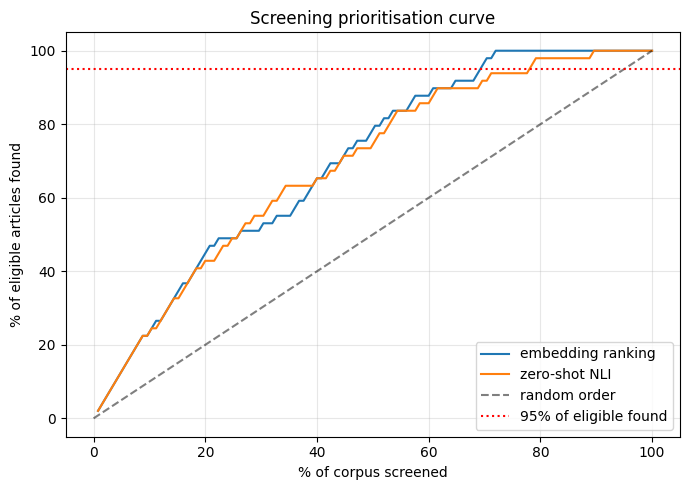

embedding : 95% of eligible found after screening 69.6% of the corpus | RRF@10 (found in first 10%) = 24.5%
NLI       : 95% of eligible found after screening 78.4% of the corpus | RRF@10 (found in first 10%) = 24.5%


In [5]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

EMB_MODEL = "sentence-transformers/all-mpnet-base-v2"
emb = SentenceTransformer(EMB_MODEL)
print(f"Loaded {EMB_MODEL}")

# seeds: the positives you already labelled in real.json (NOT from the diagnostic set,
# which must stay untouched for evaluation)
real = pd.DataFrame(json.load(open(f"{DATA_DIR}/real.json", encoding="utf-8")))
seeds_pos = real[real["label"] == POS]["text"].tolist()
seeds_neg = real[real["label"] == NEG]["text"].tolist()
print(f"Seeds: {len(seeds_pos)} positive | {len(seeds_neg)} negative")

E_diag = emb.encode(diag["text"].tolist(), show_progress_bar=True, normalize_embeddings=True)
E_pos  = emb.encode(seeds_pos, normalize_embeddings=True)
E_neg  = emb.encode(seeds_neg, normalize_embeddings=True)

sim_pos = cosine_similarity(E_diag, E_pos).max(axis=1)
sim_neg = cosine_similarity(E_diag, E_neg).max(axis=1)
raw = sim_pos - sim_neg
diag["emb_score"] = (raw - raw.min()) / (raw.max() - raw.min())   # rescale to 0-1

t_emb = sweep_table(y, diag["emb_score"].values, "EMBEDDING SIMILARITY (pos - neg)")

# --- the prioritisation view: how fast do eligible papers accumulate? ---
order = np.argsort(-diag["emb_score"].values)
cum = np.cumsum(y[order]) / y.sum()
frac = np.arange(1, len(y) + 1) / len(y)

plt.figure(figsize=(7, 5))
plt.plot(frac * 100, cum * 100, label="embedding ranking")
nli_order = np.argsort(-diag["nli_score"].values)
plt.plot(frac * 100, np.cumsum(y[nli_order]) / y.sum() * 100, label="zero-shot NLI")
plt.plot([0, 100], [0, 100], "k--", alpha=.5, label="random order")
plt.axhline(95, color="red", ls=":", label="95% of eligible found")
plt.xlabel("% of corpus screened"); plt.ylabel("% of eligible articles found")
plt.title("Screening prioritisation curve"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

for name, s in [("embedding", diag["emb_score"].values), ("NLI", diag["nli_score"].values)]:
    o = np.argsort(-s); c = np.cumsum(y[o]) / y.sum()
    idx = np.argmax(c >= 0.95)
    print(f"{name:10s}: 95% of eligible found after screening "
          f"{100*(idx+1)/len(y):.1f}% of the corpus "
          f"| RRF@10 (found in first 10%) = {c[int(.1*len(y))]*100:.1f}%")

In [6]:
# ============================================================
# Head-to-head: everything measured on the same 125 real abstracts
# ============================================================
FINETUNED = {"approach": "Fine-tuned DeBERTa (synthetic training)",
             "recall@thr": 0.980, "precision": 0.449,
             "pct_discarded": 14.4, "WSS@95": 12.4}

def summarise(name, score):
    r = wss_at_recall(y, score, 0.95)
    if r is None:
        return {"approach": name, "recall@thr": np.nan, "precision": np.nan,
                "pct_discarded": np.nan, "WSS@95": np.nan}
    wss, thr, rec, frac = r
    pred = (score >= thr).astype(int)
    return {"approach": name, "recall@thr": round(rec, 3),
            "precision": round(precision_score(y, pred, zero_division=0), 3),
            "pct_discarded": round(100 * (1 - frac), 1), "WSS@95": round(wss * 100, 1)}

comp = pd.DataFrame([FINETUNED,
                     summarise("Zero-shot NLI (no training)", diag["nli_score"].values),
                     summarise("Embedding similarity (67 seeds)", diag["emb_score"].values)])
print(comp.to_string(index=False))
print("\nBenchmark (O'Mara-Eves et al. 2015): 30-70% workload saving at ~95% recall.")
print("Whichever wins, report all three: the comparison is itself a finding.")

diag.to_json(f"{OUT_DIR}/local_zeroshot_results.json",
             orient="records", indent=2, force_ascii=False)

# which hypothesis fired on the misses? tells you what wording to fix
miss = diag[(diag.y == 1) & (diag.nli_score < 0.3)]
print(f"\nEligible articles scored low by NLI ({len(miss)}) - hypothesis wording to review:")
print(miss["nli_best_pos"].value_counts().to_string())

                               approach  recall@thr  precision  pct_discarded  WSS@95
Fine-tuned DeBERTa (synthetic training)       0.980      0.449           14.4    12.4
            Zero-shot NLI (no training)       0.959      0.480           21.6    17.5
        Embedding similarity (67 seeds)       0.980      0.545           29.6    27.6

Benchmark (O'Mara-Eves et al. 2015): 30-70% workload saving at ~95% recall.
Whichever wins, report all three: the comparison is itself a finding.

Eligible articles scored low by NLI (30) - hypothesis wording to review:
nli_best_pos
This study measures pedestrian crossings, street lighting or traffic exposure with sensors.    7
This study measures thermal comfort, noise or air quality at pedestrian level.                 7
This study uses sensors to measure the physical condition of sidewalks or footpaths.           6
This study measures slope, steps, ramps or accessibility barriers along pedestrian routes.     6
This study measures street greener

## If neither is good enough

Options that still avoid a paid API, in order of effort:

1. **Rewrite the hypotheses.** The NLI score is very sensitive to wording. Use the
   failure analysis in the last cell: if eligible papers keep matching one weak
   hypothesis, that sentence needs to be split or made more concrete.
2. **Free-tier hosted models.** Google AI Studio, Groq and OpenRouter all offer free
   quotas large enough for ~1,600 abstracts. Same prompt as the API notebook.
3. **A local instruction model via Ollama** (`llama3.1:8b`, `qwen2.5:7b`). Runs the full
   four-rule prompt offline. Needs ~8 GB VRAM and a few hours for the corpus.
4. **Active learning with the linear baseline.** TF-IDF + logistic regression, retrained
   after each batch of 50 hand-labelled abstracts chosen by uncertainty. Reaches target
   recall with far fewer labels than random annotation (Wallace et al. 2010).
5. **Prioritised manual screening.** Use the ranking curve above, screen in that order,
   and report where you stopped. Honest, defensible, and needs nothing else.